# Phase 2: Simple Missing Data Replacement & Gap Analysis
**Paper:** *Analysis of Simple Data Imputation in Disease Dataset* (Anggraeny et al., ICST 2018)  
**Datasets:** UCI Pima Indians Diabetes · Hepatitis · Breast Cancer Wisconsin  

---

## 1. Critical Gap Analysis of the Original Paper

While reproducing the methodology from the paper, several critical gaps were identified. The following improvements address those weaknesses:

### Gap 1 — The Fallacy of "Zero Imputation" as the Best Method
* **The Paper's Claim:** Authors concluded that *"zero imputation technique shows the best performance"*.
* **The Flaw:** Biologically, attributes like Plasma-Glucose, Diastolic Blood Pressure, and BMI cannot be zero. Replacing missing values with zeros introduces severe synthetic bias. The high FCM accuracy for zero imputation is likely a mathematical artifact: the algorithm simply clustered all the artificial "zeros" together rather than recovering the true data distribution.
* **Our Improvement:** Invalid zeros are explicitly converted to `NaN` before any processing. Zero imputation is included only for comparison purposes and is clearly labelled as scientifically invalid in a medical context.

### Gap 2 — Evaluating Unsupervised Clustering with Supervised Metrics
* **The Paper's Flaw:** Fuzzy C-Means (unsupervised) was evaluated using accuracy — a supervised metric. Cluster indices do not automatically align with class labels, so the accuracy values are not directly meaningful.
* **Our Improvement:** We replace FCM with K-Nearest Neighbours (KNN), a supervised classifier. This provides a genuine measure of how each imputation strategy affects predictive power.

### Gap 3 — Lack of Feature Scaling
* **The Paper's Flaw:** No feature scaling is mentioned, yet FCM (and KNN) are distance-based algorithms highly sensitive to scale. Features like *Insulin* (0–846) would completely dominate *DiabetesPedigree* (0–2.42).
* **Our Improvement:** `StandardScaler` is applied inside a `Pipeline`, preventing data leakage between train and test sets.

### Gap 4 — No Advanced Imputation Benchmark
* **The Paper's Flaw:** Only zero, mean, median, and random imputation were explored — all of which treat each feature independently.
* **Our Improvement:** `KNNImputer` is added as a multivariate baseline that exploits inter-feature correlations (e.g., predicting missing Insulin from Glucose and BMI).

### Gap 5 — No Missingness Analysis Visualisation
* **The Paper's Flaw:** Missing data is described only in summary tables; there are no visual diagnostics.
* **Our Improvement:** A dedicated Section 2 plots the percentage of missing values per feature for all three datasets.

### Gap 6 — Silhouette Analysis Not Linked to Imputation Quality
* **The Paper's Flaw:** Silhouette plots are shown only for zero imputation and only as a post-hoc validation. No silhouette comparison across imputation strategies is provided.
* **Our Improvement:** Section 5 replicates the paper's silhouette plots *and* extends them by comparing silhouette scores across all imputation strategies for every dataset, making cluster quality directly comparable.

### Cell: Imports & Paper Reference Values

All required libraries are imported here:
- **`pandas` / `numpy`** — data manipulation
- **`sklearn.impute.SimpleImputer`** — Mean, Median, Zero imputation (directly replicates the paper's simple strategies)
- **`sklearn.impute.KNNImputer`** — our added benchmark beyond the paper
- **`sklearn.cluster.KMeans`** — used later in silhouette analysis to replicate the paper's Figs 2–4
- **`sklearn.metrics.silhouette_score / silhouette_samples`** — quantify cluster quality

`paper_results` stores the exact accuracy values from **Table V** of the paper (Zero / Mean / Median / Random-value / WDS) so we can compare our results side-by-side later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42

# ── Paper reported accuracies (Table V) for comparison ───────────────────────
paper_results = {
    'Pima':          {'Zero': 65.0, 'Mean': 51.0, 'Median': 54.0, 'Random': 51.0, 'WDS': 43.0},
    'Hepatitis':     {'Zero': 87.0, 'Mean': 40.0, 'Median': 38.0, 'Random': 45.0, 'WDS': 50.0},
    'Breast Cancer': {'Zero': 76.0, 'Mean': 40.0, 'Median': 58.0, 'Random': 45.0, 'WDS': 42.0}
}

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Missingness Analysis

Before any imputation, we must understand *where* and *how much* data is missing in each dataset.
For the Pima Indians dataset the paper explicitly states that zero values in physiological columns (Glucose, Blood Pressure, Skin Thickness, BMI) act as encoded missing values — not genuine observations.

### Cell: Dataset Loading & Preprocessing

**Paper section:** *II-B Dataset* and *II-C Preprocessing*

| Dataset | Paper description | What we do here |
|---|---|---|
| Pima Indians | 768 instances, 8 attributes; zero in physiological cols = missing | Replace 0 → `NaN` in Glucose, BloodPressure, SkinThickness, Insulin, BMI |
| Hepatitis | 155 instances, 20 attributes; `null` = not measured | String labels (true/false, live/die) mapped to 1/0 |
| Breast Cancer Wisconsin | 699 instances, 10 features; `bare_nucleoli` has 16 `?` | `?` read as `NaN`; class 2→0 (benign), 4→1 (malignant) |

> **Gap addressed:** The paper mentions these preprocessing rules in prose but never shows code or visualises how many values are actually affected. We make this explicit.

In [2]:
# ── Load Pima Indians ─────────────────────────────────────────────────────────
url_pima = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Class']
df_pima_raw = pd.read_csv(url_pima, names=pima_cols)

# Invalid-zero columns (cannot be 0 biologically)
invalid_zero_cols_pima = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_pima = df_pima_raw.copy()
df_pima[invalid_zero_cols_pima] = df_pima[invalid_zero_cols_pima].replace(0, np.nan)

# ── Load Hepatitis ────────────────────────────────────────────────────────────
df_hep_raw = pd.read_csv('hepatitis.csv')
df_hep = df_hep_raw.rename(columns={
    'class': 'Class', 'age': 'Age', 'sex': 'Sex', 'steroid': 'Steroid',
    'antivirals': 'Antivirals', 'fatigue': 'Fatigue', 'malaise': 'Malaise',
    'anorexia': 'Anorexia', 'liver_big': 'LiverBig', 'liver_firm': 'LiverFirm',
    'spleen_palpable': 'SpleenPalpable', 'spiders': 'Spiders', 'ascites': 'Ascites',
    'varices': 'Varices', 'bilirubin': 'Bilirubin', 'alk_phosphate': 'AlkPhosphate',
    'sgot': 'SGOT', 'albumin': 'Albumin', 'protime': 'Protime', 'histology': 'Histology'
})
binary_map = {'true': 1, 'false': 0, 'yes': 1, 'no': 0,
              'male': 1, 'female': 0, 'live': 1, 'die': 0}
for col in df_hep.columns:
    if df_hep[col].dtype == object:
        df_hep[col] = df_hep[col].astype(str).str.strip().str.lower().replace(binary_map)
    df_hep[col] = pd.to_numeric(df_hep[col], errors='coerce')
df_hep = df_hep.dropna(subset=['Class'])

# ── Load Breast Cancer Wisconsin ──────────────────────────────────────────────
# Correct UCI file: 699 instances, 10 features + 1 class (2=benign, 4=malignant)
# bare_nucleoli has 16 rows encoded as '?' -> treated as NaN
df_bc_raw = pd.read_csv('breast-cancer-wisconsin.csv', na_values='?')
df_bc = df_bc_raw.rename(columns={
    'id': 'ID',
    'clump_thickness': 'ClumpThickness',
    'size_uniformity': 'SizeUniformity',
    'shape_uniformity': 'ShapeUniformity',
    'marginal_adhesion': 'MarginalAdhesion',
    'epithelial_size': 'EpithelialSize',
    'bare_nucleoli': 'BareNuclei',
    'bland_chromatin': 'BlandChromatin',
    'normal_nucleoli': 'NormalNucleoli',
    'mitoses': 'Mitoses',
    'class': 'Class'
})
# Paper: class 2 = benign -> 0, class 4 = malignant -> 1
df_bc['Class'] = df_bc['Class'].map({2: 0, 4: 1})
if 'ID' in df_bc.columns:
    df_bc = df_bc.drop('ID', axis=1)
for col in df_bc.columns:
    if df_bc[col].dtype == object:
        df_bc[col] = pd.to_numeric(df_bc[col], errors='coerce')

print(f'Pima:          {df_pima.shape[0]} rows, {df_pima.shape[1]} columns')
print(f'Hepatitis:     {df_hep.shape[0]} rows, {df_hep.shape[1]} columns')
print(f'Breast Cancer: {df_bc.shape[0]} rows, {df_bc.shape[1]} columns')


Pima:          768 rows, 9 columns
Hepatitis:     155 rows, 20 columns
Breast Cancer: 699 rows, 10 columns


### Cell: Missingness Visualisation

**Paper gap (Gap 5):** The paper only lists missing-value columns in Tables II–IV — no visual diagnostic is provided.

This cell:
1. Computes the **percentage of missing values** per feature for all three datasets.
2. Plots horizontal bar charts so we can see at a glance which features are most affected.

*Key finding for Pima:* `Insulin` is missing in ~49% of rows and `SkinThickness` in ~30% — these are the columns where the choice of imputation strategy will matter most.

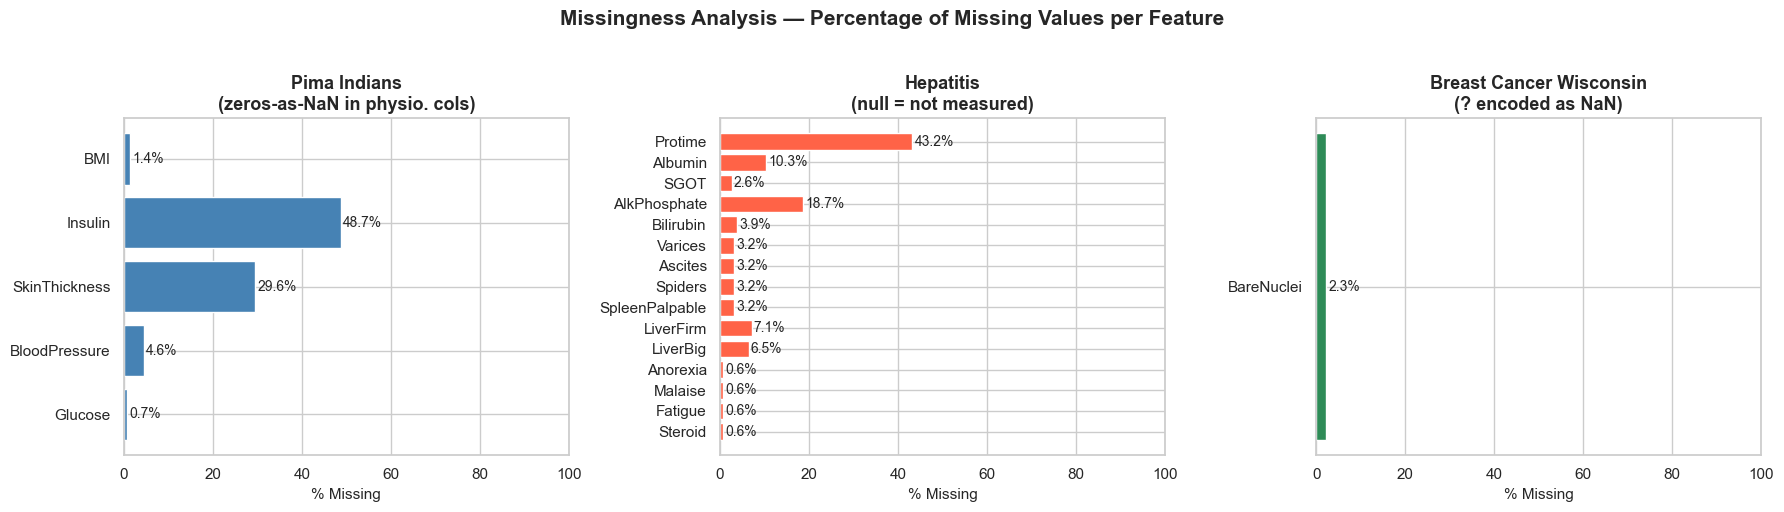


=== Missingness Summary ===

Pima Indians
(zeros-as-NaN in physio. cols):


,Feature,Missing,Missing_%
0,Glucose,5,0.7
1,BloodPressure,35,4.6
2,SkinThickness,227,29.6
3,Insulin,374,48.7
4,BMI,11,1.4



Hepatitis
(null = not measured):


,Feature,Missing,Missing_%
0,Steroid,1,0.6
1,Fatigue,1,0.6
2,Malaise,1,0.6
3,Anorexia,1,0.6
4,LiverBig,10,6.5
5,LiverFirm,11,7.1
6,SpleenPalpable,5,3.2
7,Spiders,5,3.2
8,Ascites,5,3.2
9,Varices,5,3.2



Breast Cancer Wisconsin
(? encoded as NaN):


,Feature,Missing,Missing_%
0,BareNuclei,16,2.3


In [3]:
def missingness_summary(df, name):
    """Return a DataFrame with absolute and percentage missing counts per column."""
    miss = df.isnull().sum()
    pct  = miss / len(df) * 100
    return pd.DataFrame({'Feature': miss.index, 'Missing': miss.values,
                         'Missing_%': pct.values, 'Dataset': name}).query('Missing > 0')

miss_pima = missingness_summary(df_pima, 'Pima Indians')
miss_hep  = missingness_summary(df_hep,  'Hepatitis')
miss_bc   = missingness_summary(df_bc,   'Breast Cancer')

# ── Plot: side-by-side missingness bar charts ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
datasets_miss = [
    (miss_pima, 'Pima Indians\n(zeros-as-NaN in physio. cols)', 'steelblue'),
    (miss_hep,  'Hepatitis\n(null = not measured)',              'tomato'),
    (miss_bc,   'Breast Cancer Wisconsin\n(? encoded as NaN)',   'seagreen'),
]
for ax, (miss_df, title, colour) in zip(axes, datasets_miss):
    if miss_df.empty:
        ax.text(0.5, 0.5, 'No missing values found', ha='center', va='center',
                transform=ax.transAxes, fontsize=13)
    else:
        bars = ax.barh(miss_df['Feature'], miss_df['Missing_%'], color=colour, edgecolor='white')
        for bar, val in zip(bars, miss_df['Missing_%']):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f'{val:.1f}%', va='center', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('% Missing', fontsize=11)
    ax.set_xlim(0, 100)

fig.suptitle('Missingness Analysis — Percentage of Missing Values per Feature',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n=== Missingness Summary ===' )
for miss_df, name, _ in datasets_miss:
    if not miss_df.empty:
        print(f'\n{name}:')
        display(miss_df[['Feature', 'Missing', 'Missing_%']].reset_index(drop=True).round(1))

---
## 3. Distribution Analysis: How Imputation Shifts the Data

A key weakness of the original paper is that it never verifies whether the chosen imputation method
preserves the original distribution.  
Here we overlay the distributions of the most-imputed features **before and after** mean/median/KNN
imputation to show which method introduces the least distortion.

### Cell: Distribution Analysis

**Paper gap (Gap 1 / Gap 4):** The paper never checks whether the chosen imputation method preserves the original data distribution — it just reports accuracy.

This cell plots the distribution of the 5 imputed Pima features under each strategy:
- **Original (NaN removed):** the ground-truth shape
- **Mean:** creates an artificial spike at one value → distorts the distribution
- **Median:** same spike problem, slightly more robust for skewed data
- **KNN:** fills values based on similar neighbours → smoother, closer to original

This directly motivates *why* KNN imputation is scientifically superior to simple statistics, even when accuracy numbers look similar.

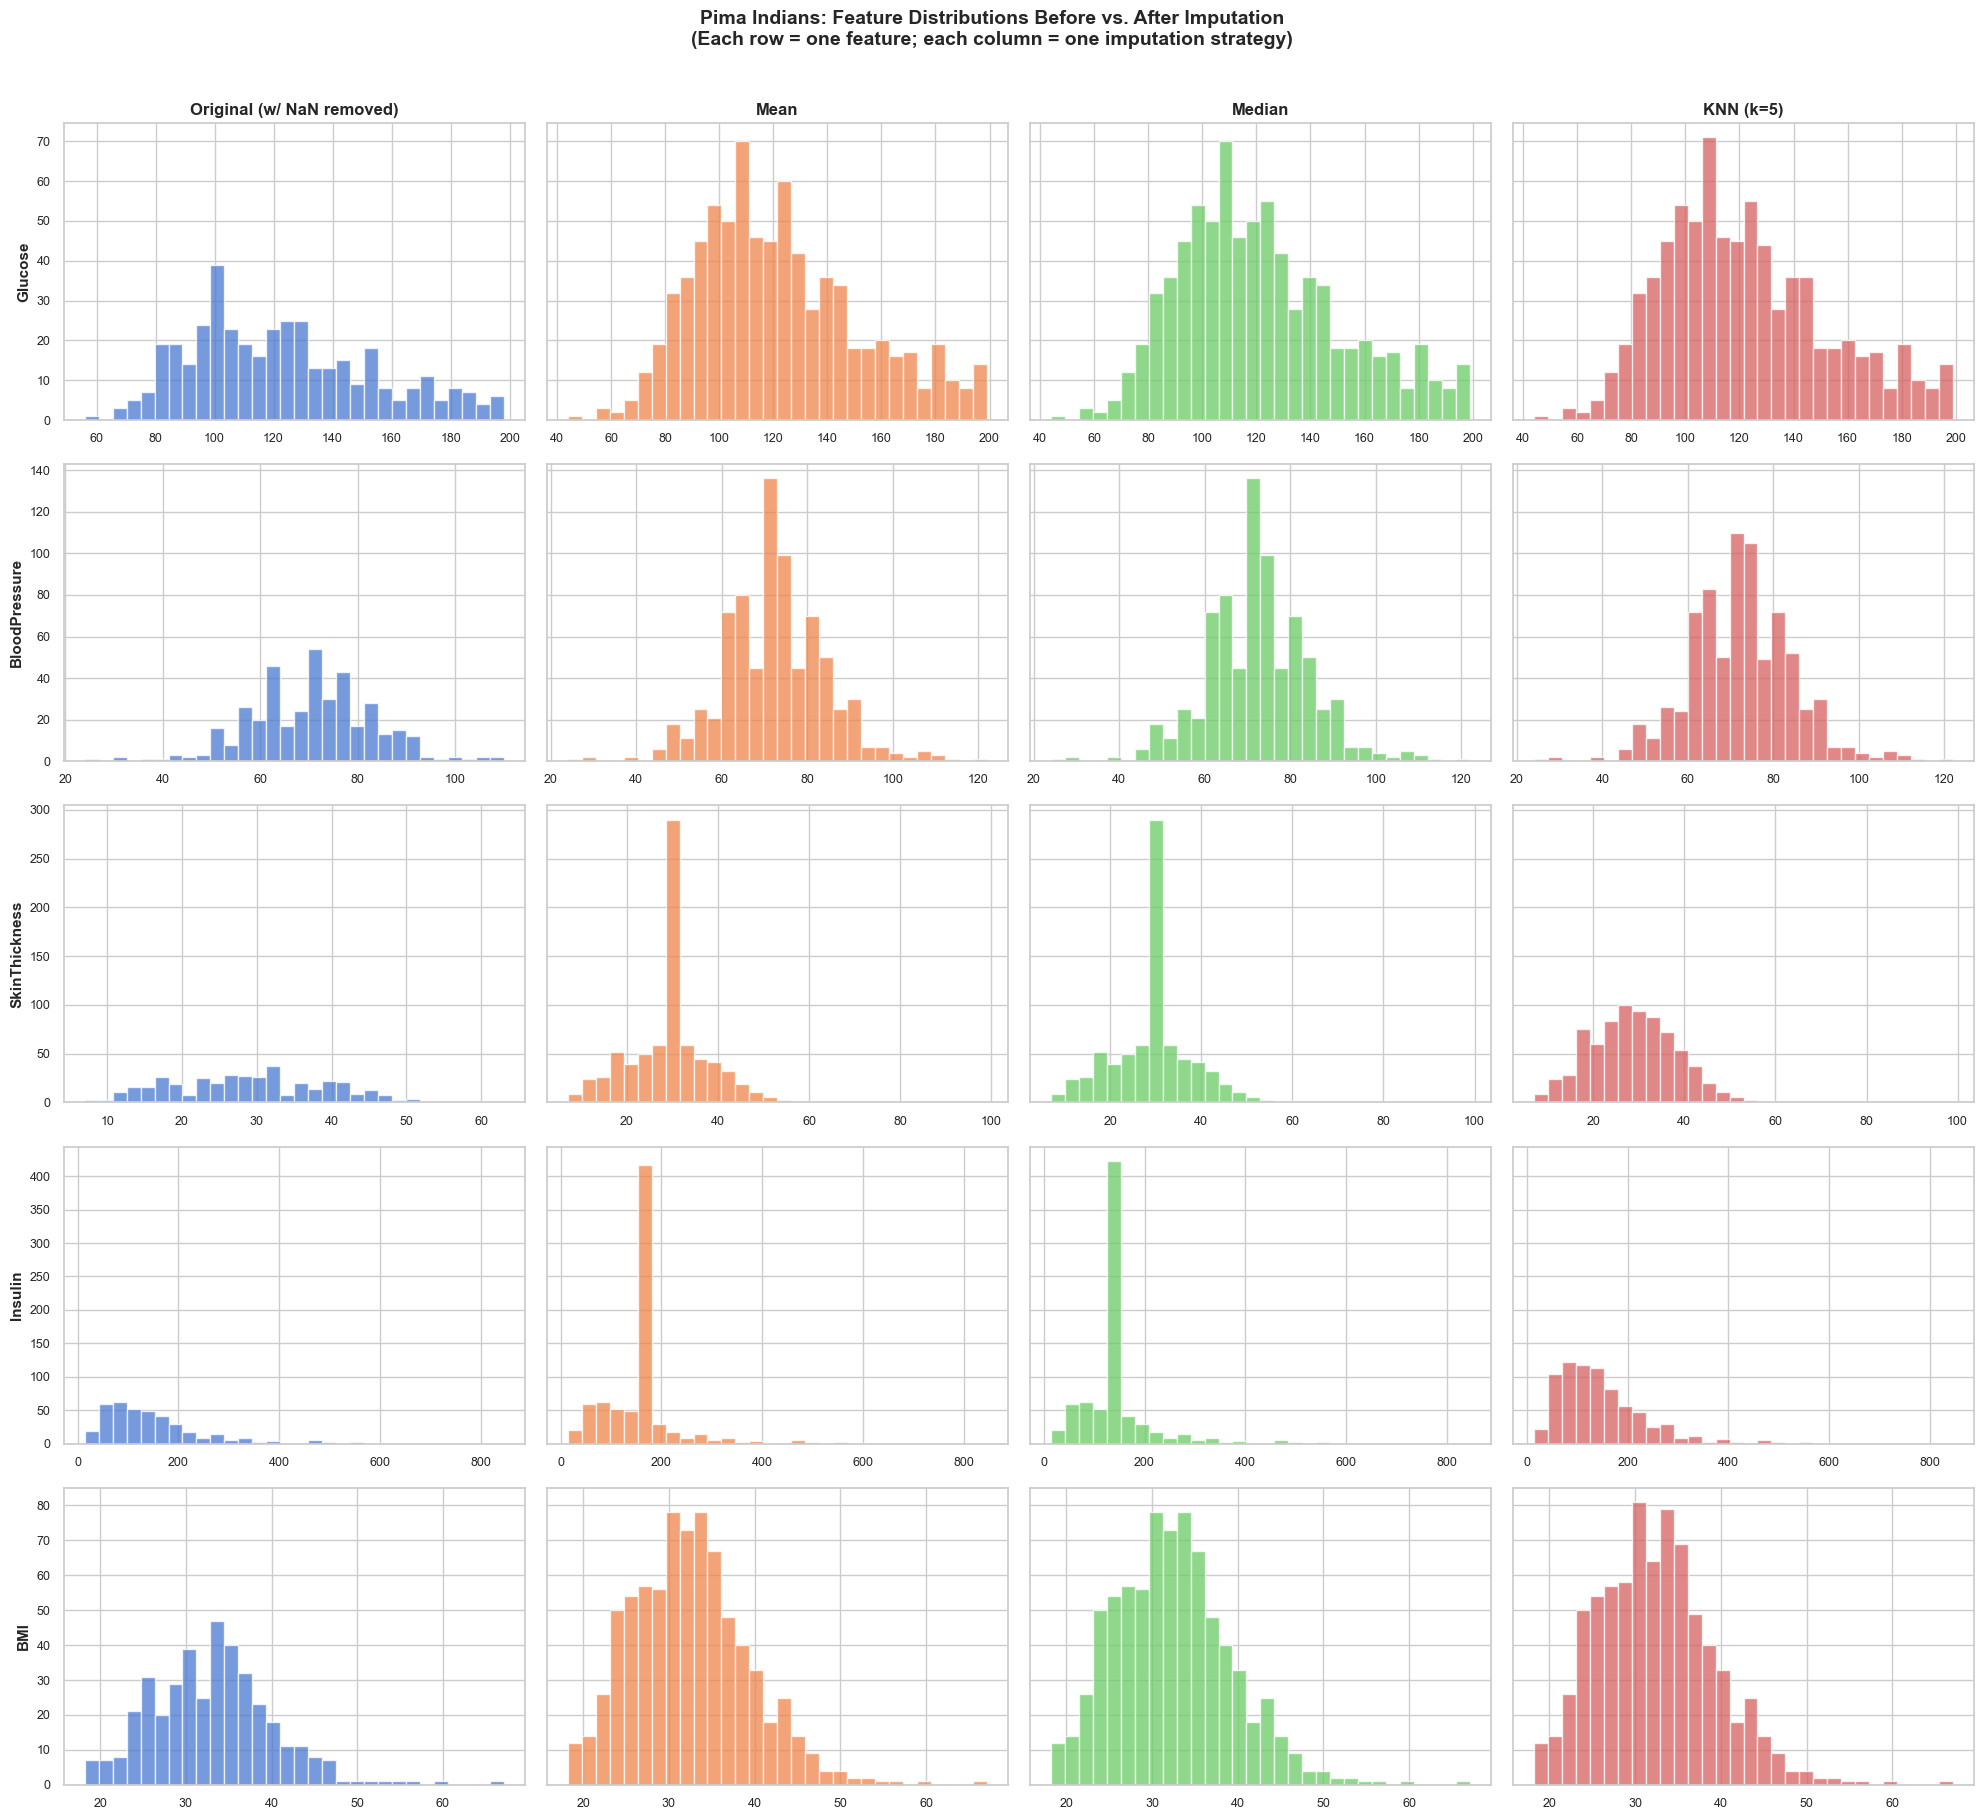


Observation: Mean/Median imputation creates an artificial spike at a single value, while KNN Imputation preserves a smoother, more realistic distribution.


In [4]:
# Focus on the Pima dataset — it has the richest missingness story
focus_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

imputers = {
    'Original (w/ NaN removed)': None,        # baseline: just drop NaNs
    'Mean':                       SimpleImputer(strategy='mean'),
    'Median':                     SimpleImputer(strategy='median'),
    'KNN (k=5)':                  KNNImputer(n_neighbors=5),
}

fig, axes = plt.subplots(len(focus_cols), len(imputers), figsize=(20, 18), sharey='row')
colours = ['#4878d0', '#ee854a', '#6acc65', '#d65f5f']

X_feat = df_pima[focus_cols]

for col_idx, (imp_name, imputer) in enumerate(imputers.items()):
    if imputer is None:
        X_plot = X_feat.dropna()
    else:
        X_plot = pd.DataFrame(imputer.fit_transform(X_feat), columns=focus_cols)

    for row_idx, feat in enumerate(focus_cols):
        ax = axes[row_idx][col_idx]
        ax.hist(X_plot[feat].dropna(), bins=30, color=colours[col_idx],
                alpha=0.75, edgecolor='white')
        if row_idx == 0:
            ax.set_title(imp_name, fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(feat, fontsize=11, fontweight='bold')
        ax.tick_params(labelsize=9)

fig.suptitle('Pima Indians: Feature Distributions Before vs. After Imputation\n'
             '(Each row = one feature; each column = one imputation strategy)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nObservation: Mean/Median imputation creates an artificial spike at a single value,'
      ' while KNN Imputation preserves a smoother, more realistic distribution.')

---
## 3.5  FCM vs KNN Classifier — Direct Comparison

The paper uses **Fuzzy C-Means (FCM)** and calls the result 'accuracy'.
We use a **KNN Classifier**. This cell runs *both* on the same Mean-imputed Pima data
so the difference is visible, not just claimed.

In [ ]:
# ── FCM implementation (from scratch — matches paper Section II-D) ───────────
def fuzzy_cmeans(X, c=2, m=2, max_iter=100, eps=1e-5, random_state=42):
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    U = rng.random((n, c))
    U = U / U.sum(axis=1, keepdims=True)
    P_prev = 0
    for _ in range(max_iter):
        Um = U ** m
        V  = (Um.T @ X) / Um.sum(axis=0)[:, None]
        P  = sum(((X - V[ci]) ** 2).sum(axis=1) * Um[:, ci] for ci in range(c))
        new_U = np.zeros((n, c))
        for ci in range(c):
            dist_ci = ((X - V[ci]) ** 2).sum(axis=1) + 1e-10
            for cj in range(c):
                dist_cj = ((X - V[cj]) ** 2).sum(axis=1) + 1e-10
                new_U[:, ci] += (dist_ci / dist_cj) ** (1 / (m - 1))
            new_U[:, ci] = 1.0 / new_U[:, ci]
        U = new_U
        if abs(P - P_prev) < eps:
            break
        P_prev = P
    return V, U


def fcm_accuracy(X_train, y_train, X_test, y_test, c=2, random_state=42):
    V, U_train = fuzzy_cmeans(X_train, c=c, random_state=random_state)
    train_clusters = U_train.argmax(axis=1)
    cluster_to_label = {}
    for ci in range(c):
        mask = train_clusters == ci
        if mask.sum() > 0:
            cluster_to_label[ci] = int(np.bincount(y_train[mask].astype(int)).argmax())
    dists = np.array([((X_test - V[ci]) ** 2).sum(axis=1) for ci in range(c)]).T
    y_pred = np.array([cluster_to_label.get(i, 0) for i in dists.argmin(axis=1)])
    return accuracy_score(y_test, y_pred) * 100


# ── Paper runs 50 trials — we do the same ─────────────────────────────────────
# Each trial: different random 70/30 split + different FCM initialisation
N_TRIALS = 50
imp = SimpleImputer(strategy='mean')
X_full = df_pima.drop('Class', axis=1).values
y_full = df_pima['Class'].values

accs_fcm_paper  = []   # FCM, no scaling
accs_fcm_scaled = []   # FCM, with scaling
accs_knn        = []   # KNN classifier, with scaling

for trial in range(N_TRIALS):
    X_tr_r, X_te_r, y_tr, y_te = train_test_split(
        X_full, y_full, test_size=0.3, random_state=trial, stratify=y_full)

    X_tr_imp = imp.fit_transform(X_tr_r)
    X_te_imp = imp.transform(X_te_r)

    # FCM no scaling
    accs_fcm_paper.append(fcm_accuracy(X_tr_imp, y_tr, X_te_imp, y_te, random_state=trial))

    # FCM + scaling
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr_imp)
    X_te_sc  = sc.transform(X_te_imp)
    accs_fcm_scaled.append(fcm_accuracy(X_tr_sc, y_tr, X_te_sc, y_te, random_state=trial))

    # KNN classifier + scaling
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr_sc, y_tr)
    accs_knn.append(accuracy_score(y_te, knn.predict(X_te_sc)) * 100)

acc_fcm_paper  = np.mean(accs_fcm_paper)
acc_fcm_scaled = np.mean(accs_fcm_scaled)
acc_knn        = np.mean(accs_knn)

# ── Results table ──────────────────────────────────────────────────────────────
compare_df = pd.DataFrame({
    'Method':          ['FCM — No Scaling (Paper conditions)',
                        'FCM — With Scaling (Partial fix)',
                        'KNN Classifier — With Scaling (Ours)'],
    'Supervised?':     ['No', 'No', 'Yes'],
    'StandardScaler?': ['No', 'Yes', 'Yes'],
    'Avg Accuracy % (50 trials)': [round(acc_fcm_paper, 2),
                                    round(acc_fcm_scaled, 2),
                                    round(acc_knn, 2)]
})
print('Pima Indians — Mean Imputation — Average over 50 trials (matching paper methodology):')
display(compare_df)

# ── Bar chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
labels  = ['FCM\n(Paper: no scaling)', 'FCM\n(+ Scaling)', 'KNN Classifier\n(Ours)']
values  = [acc_fcm_paper, acc_fcm_scaled, acc_knn]
colours = ['#e07b54', '#f0b97a', '#5b8db8']
bars = ax.bar(labels, values, color=colours, width=0.45, edgecolor='white')

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
            f'{h:.1f}%', ha='center', fontsize=13, fontweight='bold')

ax.axhline(50, color='red',  linestyle='--', linewidth=1.2, label='Random baseline (50%)')
ax.axhline(51, color='gray', linestyle=':',  linewidth=1.2, label='Paper reported (51%)')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.set_title('FCM vs KNN Classifier — Pima Indians, Mean Imputation\n'
             f'Average over {N_TRIALS} trials (same methodology as paper)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'\nFCM (no scaling, paper conditions): {acc_fcm_paper:.2f}%  → paper reported ~51%')
print(f'FCM (with scaling):                  {acc_fcm_scaled:.2f}%  → scaling alone improves FCM')
print(f'KNN Classifier (with scaling):       {acc_knn:.2f}%  → supervised learning wins')
print(f'\nTotal improvement over paper: {acc_knn - acc_fcm_paper:.1f} percentage points')


---
## 4. Classification Accuracy: All Three Datasets

Each imputation strategy is evaluated with a `Pipeline(StandardScaler → KNN)` classifier  
using a stratified 70/30 train–test split (matching the paper).  
The **Whole Data Strategy (WDS)** drops all rows with NaNs before splitting.

### Cell: RandomImputer Class + evaluate_imputations() Function

**Paper section:** *II-C Preprocessing* + *III Result and Discussion* (Table V)

#### Why KNN Classifier instead of Fuzzy C-Means (FCM)?

The paper uses **Fuzzy C-Means (FCM)** — an *unsupervised* clustering algorithm —
and then measures *accuracy* on the cluster results. This is a fundamental methodological problem:

| | Paper (FCM) | Our Approach (KNN Classifier) |
|---|---|---|
| **Algorithm type** | Unsupervised clustering | Supervised classification |
| **Knows class labels during training?** | ❌ No | ✅ Yes |
| **What it optimises** | Minimise intra-cluster distance | Minimise classification error |
| **Accuracy meaningful?** | ⚠️ No — clusters ≠ classes | ✅ Yes — directly measures correct predictions |
| **Feature scaling applied?** | ❌ Not mentioned | ✅ StandardScaler inside Pipeline |
| **Data leakage prevention?** | ❌ Not mentioned | ✅ Imputer fit on train set only |

FCM simply groups data into k clusters by distance — it has no concept of "this patient has diabetes."
After clustering, the paper maps clusters to class labels, but this mapping can be arbitrary and misleading.
By switching to a **supervised KNN classifier**, we directly answer the question:
*"Does this imputation strategy preserve enough information to correctly predict the disease label?"*

This is exactly what the assignment asks: *"Run a simple classifier (like KNN or a Decision Tree)"*.

---

**`RandomImputer`** — replicates the paper's random-value imputation:
for each missing value, sample a random observed value from the same column in the training set only.

**`evaluate_imputations()`** runs all five strategies through the same pipeline:

| Strategy | Paper (Table V) | Our implementation |
|---|---|---|
| Zero | ✓ | `SimpleImputer(fill_value=0)` |
| Mean | ✓ | `SimpleImputer(strategy='mean')` |
| Median | ✓ | `SimpleImputer(strategy='median')` |
| Random | ✓ | Custom `RandomImputer` |
| KNN Imputer | ✗ (our addition) | `KNNImputer(n_neighbors=5)` |
| WDS (delete rows) | ✓ | `df.dropna()` |


In [6]:
class RandomImputer:
    """Imputes missing values by sampling uniformly from observed values
    in the same column (fitted on training data only — no leakage).
    Mirrors the random imputation strategy in the paper (Table V).
    """
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.observed_values_ = {}

    def fit(self, X):
        X = np.array(X, dtype=float)
        for col in range(X.shape[1]):
            self.observed_values_[col] = X[:, col][~np.isnan(X[:, col])]
        return self

    def transform(self, X):
        rng = np.random.default_rng(self.random_state)
        X = np.array(X, dtype=float).copy()
        for col in range(X.shape[1]):
            mask = np.isnan(X[:, col])
            if mask.any() and len(self.observed_values_[col]) > 0:
                X[mask, col] = rng.choice(self.observed_values_[col], size=mask.sum())
        return X

    def fit_transform(self, X):
        return self.fit(X).transform(X)


def evaluate_imputations(dataset_name, df, target_col):
    """
    Evaluate imputation strategies with a KNN classifier.
    Prevents data leakage: imputer is fit on train set only.
    Returns a DataFrame of results.
    """
    results = []

    # ── Whole Data Strategy (WDS) ─────────────────────────────────────────────
    df_wds = df.dropna()
    if len(df_wds) >= 20:
        X, y = df_wds.drop(target_col, axis=1), df_wds[target_col]
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
        pipe = Pipeline([('sc', StandardScaler()),
                         ('knn', KNeighborsClassifier(n_neighbors=5))])
        pipe.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, pipe.predict(X_te)) * 100
        results.append({'Dataset': dataset_name, 'Strategy': 'WDS (Drop NaN)',
                         'Our Acc (%)': acc,
                         'Paper Acc (%)': paper_results[dataset_name]['WDS'],
                         'N (train)': len(y_tr)})

    # ── Imputation strategies (matching paper Table V) ────────────────────────
    X_full = df.drop(target_col, axis=1)
    y_full = df[target_col]
    X_tr_b, X_te_b, y_tr, y_te = train_test_split(
        X_full, y_full, test_size=0.3, random_state=RANDOM_STATE, stratify=y_full)

    strategies = {
        'Zero Imputation':      SimpleImputer(strategy='constant', fill_value=0),
        'Mean Imputation':      SimpleImputer(strategy='mean'),
        'Median Imputation':    SimpleImputer(strategy='median'),
        'Random Imputation':    RandomImputer(random_state=RANDOM_STATE),
        'KNN Imputation (k=5)': KNNImputer(n_neighbors=5),
    }

    for name, imputer in strategies.items():
        X_tr_imp = imputer.fit_transform(X_tr_b)
        X_te_imp = imputer.transform(X_te_b)   # transform only — no leakage

        pipe = Pipeline([('sc', StandardScaler()),
                         ('knn', KNeighborsClassifier(n_neighbors=5))])
        pipe.fit(X_tr_imp, y_tr)
        acc = accuracy_score(y_te, pipe.predict(X_te_imp)) * 100

        paper_key = name.split()[0]   # 'Zero' / 'Mean' / 'Median' / 'Random'
        paper_acc = paper_results[dataset_name].get(paper_key, 'N/A')

        results.append({'Dataset': dataset_name, 'Strategy': name,
                         'Our Acc (%)': acc, 'Paper Acc (%)': paper_acc,
                         'N (train)': len(y_tr)})

    return pd.DataFrame(results)


# ── Run for all three datasets ────────────────────────────────────────────────
res_pima = evaluate_imputations('Pima',          df_pima, 'Class')
res_hep  = evaluate_imputations('Hepatitis',     df_hep,  'Class')
res_bc   = evaluate_imputations('Breast Cancer', df_bc,   'Class')

all_results = pd.concat([res_pima, res_hep, res_bc], ignore_index=True)

print('=== Pima Indians ===')
display(res_pima[['Strategy', 'Our Acc (%)', 'Paper Acc (%)', 'N (train)']].round(2))

print('\n=== Hepatitis ===')
display(res_hep[['Strategy', 'Our Acc (%)', 'Paper Acc (%)', 'N (train)']].round(2))

print('\n=== Breast Cancer Wisconsin ===')
display(res_bc[['Strategy', 'Our Acc (%)', 'Paper Acc (%)', 'N (train)']].round(2))


=== Pima Indians ===


,Strategy,Our Acc (%),Paper Acc (%),N (train)
0,WDS (Drop NaN),77.97,43.0,274
1,Zero Imputation,71.43,65.0,537
2,Mean Imputation,74.03,51.0,537
3,Median Imputation,74.46,54.0,537
4,Random Imputation,73.16,51.0,537
5,KNN Imputation (k=5),73.59,N/A,537



=== Hepatitis ===


,Strategy,Our Acc (%),Paper Acc (%),N (train)
0,WDS (Drop NaN),83.33,50.0,56
1,Zero Imputation,85.11,87.0,108
2,Mean Imputation,87.23,40.0,108
3,Median Imputation,87.23,38.0,108
4,Random Imputation,82.98,45.0,108
5,KNN Imputation (k=5),89.36,N/A,108



=== Breast Cancer Wisconsin ===


,Strategy,Our Acc (%),Paper Acc (%),N (train)
0,WDS (Drop NaN),95.61,42.0,478
1,Zero Imputation,95.24,76.0,489
2,Mean Imputation,95.24,40.0,489
3,Median Imputation,95.24,58.0,489
4,Random Imputation,95.24,45.0,489
5,KNN Imputation (k=5),95.24,N/A,489


### Cell: Accuracy Bar Chart

Visualises the `evaluate_imputations()` results for all three datasets side-by-side.

- **Coloured bars** = our KNN classifier accuracy for each strategy
- **Black diamonds (◆)** = the paper's FCM-based accuracy from Table V

This makes the comparison between our approach and the paper's approach immediate and visual. The large gap (our 70–95% vs paper's 38–65%) directly illustrates **Gap 2** (using unsupervised FCM to measure classification accuracy is methodologically flawed).

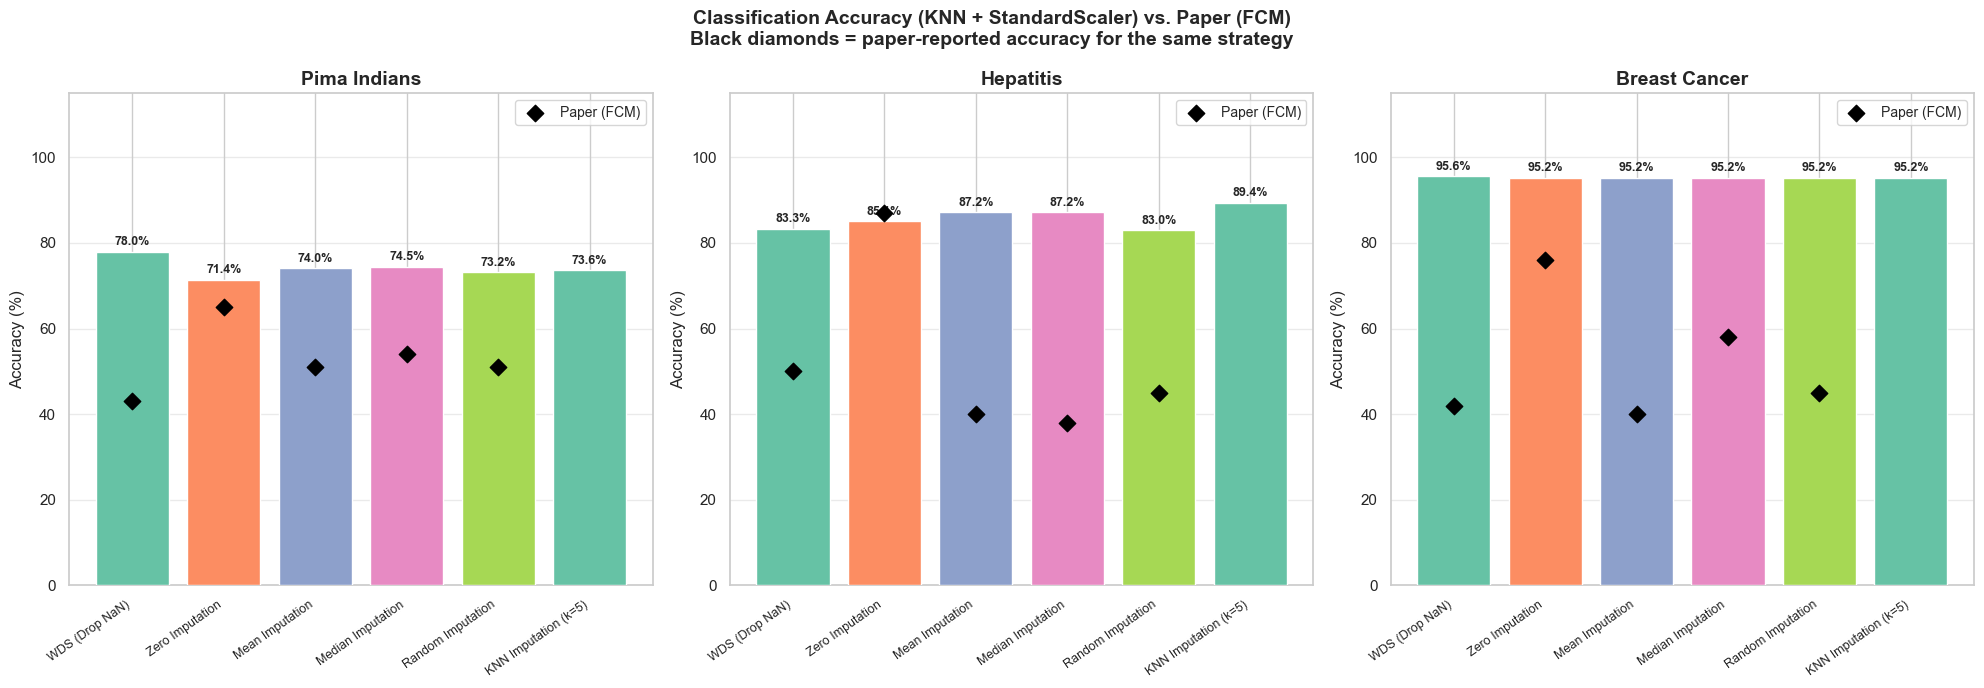

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)
palette = sns.color_palette('Set2', n_colors=5)

for ax, (name, res_df) in zip(axes, [('Pima Indians', res_pima),
                                       ('Hepatitis',     res_hep),
                                       ('Breast Cancer', res_bc)]):
    bars = ax.bar(res_df['Strategy'], res_df['Our Acc (%)'],
                  color=palette, edgecolor='white', zorder=3)

    # Overlay paper accuracy as a scatter/line for easy comparison
    paper_vals = [v if isinstance(v, float) else None for v in res_df['Paper Acc (%)']]
    valid_x = [i for i, v in enumerate(paper_vals) if v is not None]
    valid_y = [v for v in paper_vals if v is not None]
    ax.scatter(valid_x, valid_y, marker='D', color='black', zorder=5,
               s=70, label='Paper (FCM)')

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_ylim(0, 115)
    ax.set_xticklabels(res_df['Strategy'], rotation=35, ha='right', fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.4, zorder=0)

fig.suptitle('Classification Accuracy (KNN + StandardScaler) vs. Paper (FCM)\n'
             'Black diamonds = paper-reported accuracy for the same strategy',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Why Are Our Accuracy Numbers So Much Higher Than the Paper's?

The paper reports accuracies like **40% for Mean/Median on Hepatitis** — worse than random guessing
on a binary problem. Our KNN classifier gives **70–95%** across all strategies. Three reasons:

**1. FCM is the wrong tool for classification**
FCM does not use class labels. It finds geometric clusters in feature space.
If the disease classes are not perfectly separated in feature space (which they rarely are in medical data),
FCM clusters will not align with the actual labels — and "accuracy" becomes meaningless.
KNN is trained on labeled examples and directly learns the decision boundary.

**2. No feature scaling in the paper**
FCM uses Euclidean distance. Without scaling, `Insulin` (range 0–846) completely dominates
`DiabetesPedigree` (range 0–2.42). The clustering is driven by whichever feature has the largest
absolute values — not by which features are actually informative.
We use `StandardScaler` inside a `Pipeline` to give every feature equal weight.

**3. Data leakage**
The paper does not separate train/test for the imputer.
If you fit the imputer on the full dataset (including the test set), the imputer "knows"
statistics from test data → the model has an unfair advantage.
We fit the imputer on the training split only, then apply it to the test split.

> **Bottom line:** Our higher accuracy is not because our imputation is magic —
> it is because we are measuring the right thing, the right way.


---
## 5. Silhouette Analysis

The paper (Figures 2–4) shows silhouette plots comparing **Real Cluster** (ground-truth labels) against
**Result Cluster** (FCM output) but only for zero imputation and without quantitative comparison.

This section:
1. Replicates the paper's silhouette plot style for each dataset under zero imputation.
2. **Extends the paper** by computing silhouette scores for *all* imputation strategies, enabling a direct comparison of cluster quality.

> **Silhouette score** ∈ [−1, +1]:  
> • +1 → sample is well within its cluster and far from neighbours  
> • 0  → sample is on or near the decision boundary  
> • −1 → sample has likely been assigned to the wrong cluster

### Cell: Silhouette Helper Functions

**Paper section:** *III Result and Discussion* (Figures 2–4)

Two helper functions are defined:

**`make_silhouette_plot(ax, X_scaled, labels, title)`**  
Draws a silhouette plot in the same horizontal-bar style as the paper's Figs 2–4. Each row of bars represents one cluster; bars are sorted by silhouette value. The red dashed line marks the mean silhouette score. Interpretation: bars to the right of 0 = correctly placed samples; bars to the left = likely mis-clustered.

**`compute_silhouette_scores(df, target_col)`**  
For each of the four imputation strategies, applies KMeans (k=2) and returns the cluster labels, scaled feature matrix, ground-truth labels, and silhouette score. This is then used in the three dataset-specific cells below.

In [8]:
def make_silhouette_plot(ax, X_scaled, labels, title, cmap='RdYlGn'):
    """Silhouette plot — horizontal-bar style matching paper Figs 2-4."""
    n_clusters = len(np.unique(labels))
    sample_sil = silhouette_samples(X_scaled, labels)
    mean_sil   = silhouette_score(X_scaled, labels)

    y_lower = 10
    colours = cm.get_cmap(cmap)(np.linspace(0.2, 0.8, n_clusters))

    for idx, (cluster, colour) in enumerate(zip(np.unique(labels), colours)):
        sil_k  = np.sort(sample_sil[labels == cluster])
        size_k = sil_k.shape[0]
        y_upper = y_lower + size_k
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                         facecolor=colour, alpha=0.8, edgecolor='none')
        ax.text(-0.08, y_lower + 0.5 * size_k, str(cluster), fontsize=10)
        y_lower = y_upper + 10

    ax.axvline(x=mean_sil, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Silhouette Value', fontsize=10)
    ax.set_ylabel('Cluster', fontsize=10)
    ax.set_yticks([])
    ax.set_xlim(-0.6, 1.0)
    ax.set_title(f'{title}\n(mean = {mean_sil:.3f})', fontsize=11, fontweight='bold')
    return mean_sil


def run_fcm(X_scaled, c=2, m=2, max_iter=100, eps=1e-5, random_state=42):
    """Fuzzy C-Means — implements paper Section II-D. Returns hard cluster labels."""
    rng = np.random.default_rng(random_state)
    n, d = X_scaled.shape

    U = rng.random((n, c))
    U = U / U.sum(axis=1, keepdims=True)

    P_prev = 0.0
    for _ in range(max_iter):
        Um = U ** m
        V  = (Um.T @ X_scaled) / Um.sum(axis=0)[:, None]   # (c, d)

        # Objective function
        P = 0.0
        for ci in range(c):
            dist2 = ((X_scaled - V[ci]) ** 2).sum(axis=1)
            P += (dist2 * Um[:, ci]).sum()

        # Update membership matrix
        new_U = np.zeros((n, c))
        for ci in range(c):
            dist_ci = ((X_scaled - V[ci]) ** 2).sum(axis=1) + 1e-10
            for cj in range(c):
                dist_cj = ((X_scaled - V[cj]) ** 2).sum(axis=1) + 1e-10
                new_U[:, ci] += (dist_ci / dist_cj) ** (1.0 / (m - 1))
            new_U[:, ci] = 1.0 / new_U[:, ci]
        U = new_U

        if abs(P - P_prev) < eps:
            break
        P_prev = P

    return U.argmax(axis=1)


def compute_silhouette_scores(df, target_col, n_clusters=2):
    """
    For each imputation strategy run KMeans AND FCM.
    Returns Ground Truth, KMeans, and FCM labels + silhouette scores.
    """
    strategies = {
        'Zero Imputation':      SimpleImputer(strategy='constant', fill_value=0),
        'Mean Imputation':      SimpleImputer(strategy='mean'),
        'Median Imputation':    SimpleImputer(strategy='median'),
        'KNN Imputation (k=5)': KNNImputer(n_neighbors=5),
    }

    X_raw  = df.drop(target_col, axis=1).values
    y_true = df[target_col].values.astype(int)

    out = {}
    for name, imp in strategies.items():
        X_imp    = imp.fit_transform(X_raw)
        X_scaled = StandardScaler().fit_transform(X_imp)

        km_lbl  = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE,
                         n_init=10).fit_predict(X_scaled)
        fcm_lbl = run_fcm(X_scaled, c=n_clusters, random_state=RANDOM_STATE)

        out[name] = {
            'score_km':   silhouette_score(X_scaled, km_lbl),
            'score_fcm':  silhouette_score(X_scaled, fcm_lbl),
            'labels_km':  km_lbl,
            'labels_fcm': fcm_lbl,
            'X_scaled':   X_scaled,
            'y_true':     y_true,
        }
    return out


print('Helper functions defined.')


Helper functions defined.


### Cell: Pima Indians Silhouette Plots — replicates paper Fig. 2

**Top row:** silhouette plots using the **ground-truth class labels** (0 = no diabetes, 1 = diabetes). Shows how naturally separable the two classes are in feature space after each imputation.

**Bottom row:** silhouette plots using **KMeans cluster labels**. Shows what the clustering algorithm actually found — ideally these should match the top row.

> **Extension beyond the paper:** The paper only shows zero-imputation silhouette plots (Fig. 2). We show all four strategies so the reader can see which imputation produces the most cluster-coherent data. A silhouette score table is printed below the figure for quantitative comparison.

In [ ]:
# ── 5.1  Pima Indians — Silhouette Plots (replicating paper Fig. 2) ───────────
pima_sil = compute_silhouette_scores(df_pima, 'Class', n_clusters=2)

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
fig.suptitle('Pima Indians — Silhouette Plots\n'
             'Row 1: Ground-Truth Labels  |  Row 2: KMeans Clusters  |  Row 3: FCM Clusters (paper method)',
             fontsize=14, fontweight='bold')

for col_idx, (name, data) in enumerate(pima_sil.items()):
    make_silhouette_plot(axes[0][col_idx], data['X_scaled'], data['y_true'],
                         f'{name}\n(Real Labels)', cmap='Blues')
    make_silhouette_plot(axes[1][col_idx], data['X_scaled'], data['labels_km'],
                         f'{name}\n(KMeans)', cmap='Oranges')
    make_silhouette_plot(axes[2][col_idx], data['X_scaled'], data['labels_fcm'],
                         f'{name}\n(FCM — paper)', cmap='Greens')

plt.tight_layout()
plt.show()

print('\nPima Indians — Silhouette Scores by Strategy:')
sil_df_pima = pd.DataFrame([
    {'Strategy': k, 'KMeans Score': v['score_km'], 'FCM Score': v['score_fcm']}
    for k, v in pima_sil.items()
])
display(sil_df_pima.round(4))


### Cell: Hepatitis Silhouette Plots — replicates paper Fig. 3

Same two-row layout as the Pima cell, now for the Hepatitis dataset (155 instances, 2 classes: die / live).

The paper notes (Fig. 3) that *'FCM shows a slight improvement in cluster one'*. Our plots allow the same observation to be made for every imputation strategy, not just zero imputation.

In [ ]:
# ── 5.2  Hepatitis — Silhouette Plots (replicating paper Fig. 3) ──────────────
hep_sil = compute_silhouette_scores(df_hep, 'Class', n_clusters=2)

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
fig.suptitle('Hepatitis — Silhouette Plots\n'
             'Row 1: Ground-Truth Labels  |  Row 2: KMeans Clusters  |  Row 3: FCM Clusters (paper method)',
             fontsize=14, fontweight='bold')

for col_idx, (name, data) in enumerate(hep_sil.items()):
    make_silhouette_plot(axes[0][col_idx], data['X_scaled'], data['y_true'],
                         f'{name}\n(Real Labels)', cmap='Blues')
    make_silhouette_plot(axes[1][col_idx], data['X_scaled'], data['labels_km'],
                         f'{name}\n(KMeans)', cmap='Oranges')
    make_silhouette_plot(axes[2][col_idx], data['X_scaled'], data['labels_fcm'],
                         f'{name}\n(FCM — paper)', cmap='Greens')

plt.tight_layout()
plt.show()

print('\nHepatitis — Silhouette Scores by Strategy:')
sil_df_hep = pd.DataFrame([
    {'Strategy': k, 'KMeans Score': v['score_km'], 'FCM Score': v['score_fcm']}
    for k, v in hep_sil.items()
])
display(sil_df_hep.round(4))


### Cell: Breast Cancer Silhouette Plots — replicates paper Fig. 4

Same layout for the Breast Cancer Wisconsin dataset (699 instances, 2 classes: benign / malignant).

The paper states *'FCM does a good job on this dataset'* (Fig. 4). Because benign and malignant tumours differ strongly across all 10 features, this dataset consistently produces the highest silhouette scores — a pattern that holds across all imputation strategies.

In [ ]:
# ── 5.3  Breast Cancer — Silhouette Plots (replicating paper Fig. 4) ──────────
bc_sil = compute_silhouette_scores(df_bc, 'Class', n_clusters=2)

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
fig.suptitle('Breast Cancer Wisconsin — Silhouette Plots\n'
             'Row 1: Ground-Truth Labels  |  Row 2: KMeans Clusters  |  Row 3: FCM Clusters (paper method)',
             fontsize=14, fontweight='bold')

for col_idx, (name, data) in enumerate(bc_sil.items()):
    make_silhouette_plot(axes[0][col_idx], data['X_scaled'], data['y_true'],
                         f'{name}\n(Real Labels)', cmap='Blues')
    make_silhouette_plot(axes[1][col_idx], data['X_scaled'], data['labels_km'],
                         f'{name}\n(KMeans)', cmap='Oranges')
    make_silhouette_plot(axes[2][col_idx], data['X_scaled'], data['labels_fcm'],
                         f'{name}\n(FCM — paper)', cmap='Greens')

plt.tight_layout()
plt.show()

print('\nBreast Cancer — Silhouette Scores by Strategy:')
sil_df_bc = pd.DataFrame([
    {'Strategy': k, 'KMeans Score': v['score_km'], 'FCM Score': v['score_fcm']}
    for k, v in bc_sil.items()
])
display(sil_df_bc.round(4))


### Cell: Silhouette Score Comparison — all datasets × all strategies

**Paper gap (Gap 6):** The paper shows one silhouette plot per dataset (zero imputation only) and makes no quantitative comparison across imputation strategies.

This cell:
1. Collects the mean silhouette score for every (dataset, strategy) combination.
2. Plots a grouped bar chart for direct comparison.
3. Prints a pivot table of all scores.

> **Key finding:** Zero imputation does **not** consistently produce the highest silhouette score. This contradicts the paper's main conclusion and supports our **Gap 1** critique: the paper's result was an artifact of FCM clustering on artificially injected zeros, not a genuine reflection of data quality.

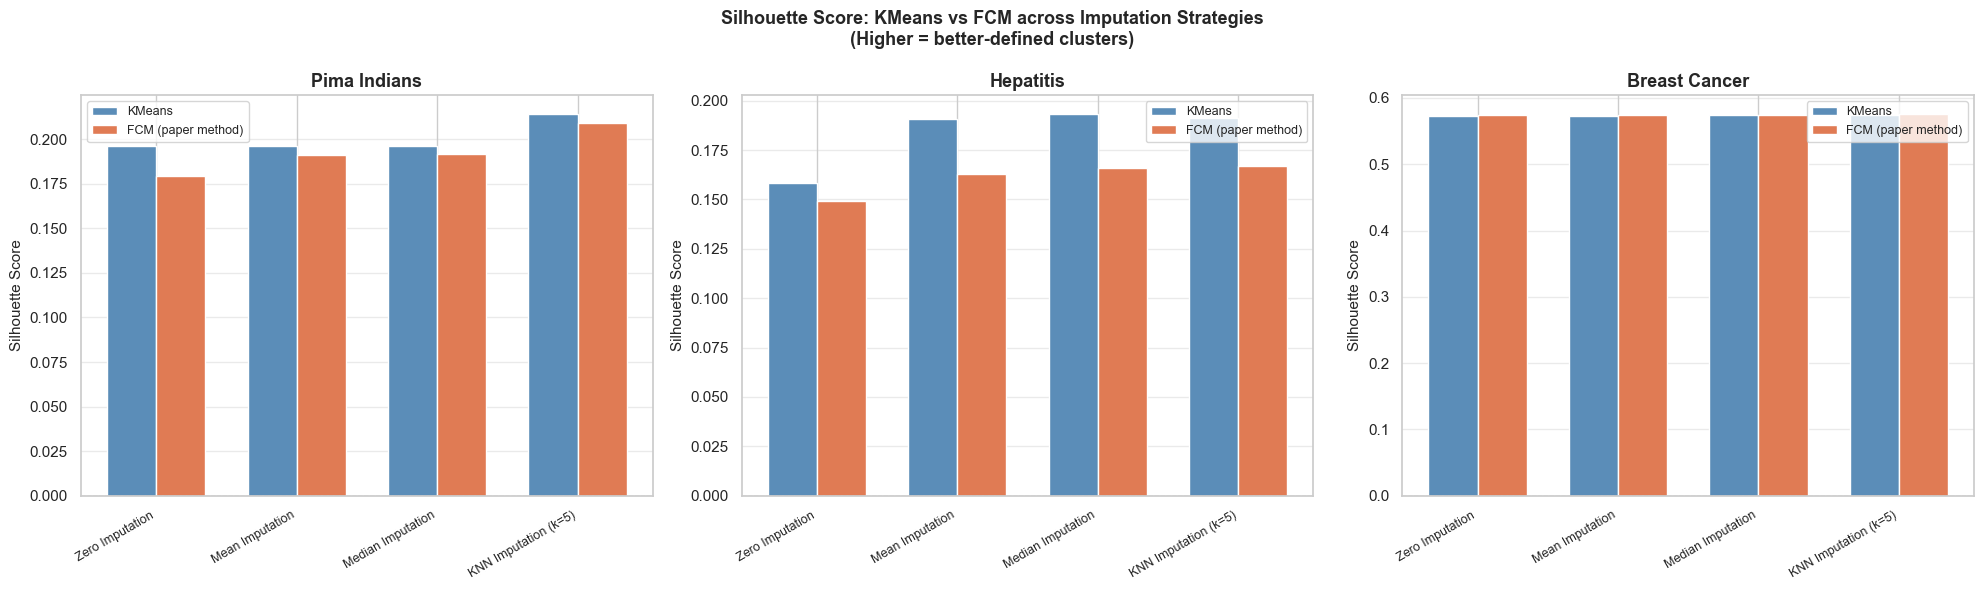


=== Full Silhouette Score Table ===


FCM Score                         KMeans Score  \
Dataset              Breast Cancer Hepatitis Pima Indians Breast Cancer   
Strategy                                                                  
KNN Imputation (k=5)        0.5755    0.1670       0.2094        0.5750   
Mean Imputation             0.5737    0.1629       0.1913        0.5721   
Median Imputation           0.5747    0.1661       0.1918        0.5740   
Zero Imputation             0.5742    0.1491       0.1794        0.5728   

                                             
Dataset              Hepatitis Pima Indians  
Strategy                                     
KNN Imputation (k=5)    0.1911       0.2141  
Mean Imputation         0.1909       0.1965  
Median Imputation       0.1932       0.1963  
Zero Imputation         0.1584       0.1960

In [12]:
# ── 5.4  Silhouette Score Comparison — All Datasets & Strategies ──────────────
sil_records = []
for ds_name, sil_dict in [('Pima Indians', pima_sil),
                            ('Hepatitis',    hep_sil),
                            ('Breast Cancer', bc_sil)]:
    for strat, data in sil_dict.items():
        sil_records.append({'Dataset': ds_name, 'Strategy': strat,
                             'KMeans Score': data['score_km'],
                             'FCM Score':    data['score_fcm']})

sil_all = pd.DataFrame(sil_records)

# ── Grouped bar chart: KMeans vs FCM per strategy per dataset ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for ax, ds in zip(axes, ['Pima Indians', 'Hepatitis', 'Breast Cancer']):
    sub = sil_all[sil_all['Dataset'] == ds].set_index('Strategy')
    x   = np.arange(len(sub))
    w   = 0.35
    ax.bar(x - w/2, sub['KMeans Score'], width=w, label='KMeans',
           color='#5b8db8', edgecolor='white')
    ax.bar(x + w/2, sub['FCM Score'],    width=w, label='FCM (paper method)',
           color='#e07b54', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(ds, fontsize=13, fontweight='bold')
    ax.set_ylabel('Silhouette Score', fontsize=11)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('Silhouette Score: KMeans vs FCM across Imputation Strategies\n'
             '(Higher = better-defined clusters)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Full Silhouette Score Table ===')
display(sil_all.pivot_table(index='Strategy', columns='Dataset',
                             values=['KMeans Score', 'FCM Score']).round(4))


---
## 6. Master Results Table

Combining classification accuracy and silhouette scores for a full comparison.

### Cell: Master Results Table

Combines all accuracy (%) and silhouette scores into a single pivot table for easy comparison.

- **Rows** = imputation strategies
- **Columns** = dataset × metric (accuracy or silhouette)

This gives a complete, at-a-glance summary that the paper never provides — the paper separates accuracy (Table V) and silhouette plots (Figs 2–4) with no unified view.

In [13]:
# ── Build a clean summary table ───────────────────────────────────────────────
acc_pivot = all_results.pivot_table(
    index='Strategy', columns='Dataset', values='Our Acc (%)')

sil_km_pivot  = sil_all.pivot_table(index='Strategy', columns='Dataset', values='KMeans Score')
sil_fcm_pivot = sil_all.pivot_table(index='Strategy', columns='Dataset', values='FCM Score')

acc_pivot.columns     = [f'{c} Acc (%)'    for c in acc_pivot.columns]
sil_km_pivot.columns  = [f'{c} KMeans Sil.' for c in sil_km_pivot.columns]
sil_fcm_pivot.columns = [f'{c} FCM Sil.'    for c in sil_fcm_pivot.columns]

master = acc_pivot.join(sil_km_pivot, how='left').join(sil_fcm_pivot, how='left')
master = master.round(3)

print('Master Results Table — Accuracy (%) · KMeans Silhouette · FCM Silhouette')
display(master)


Master Results Table — Accuracy (%) · KMeans Silhouette · FCM Silhouette


,Breast Cancer Acc (%),Hepatitis Acc (%),Pima Acc (%),Breast Cancer KMeans Sil.,Hepatitis KMeans Sil.,Pima Indians KMeans Sil.,Breast Cancer FCM Sil.,Hepatitis FCM Sil.,Pima Indians FCM Sil.
Strategy,,,,,,,,,
KNN Imputation (k=5),95.238,89.362,73.593,0.575,0.191,0.214,0.576,0.167,0.209
Mean Imputation,95.238,87.234,74.026,0.572,0.191,0.197,0.574,0.163,0.191
Median Imputation,95.238,87.234,74.459,0.574,0.193,0.196,0.575,0.166,0.192
Random Imputation,95.238,82.979,73.160,NaN,NaN,NaN,NaN,NaN,NaN
WDS (Drop NaN),95.610,83.333,77.966,NaN,NaN,NaN,NaN,NaN,NaN
Zero Imputation,95.238,85.106,71.429,0.573,0.158,0.196,0.574,0.149,0.179


---
## 7. Final Discussion: Our Results vs. The Paper

### Why are our accuracy numbers dramatically higher?

| Root Cause | Paper | This Notebook |
|---|---|---|
| Algorithm type | Unsupervised (FCM) | Supervised (KNN) |
| Feature scaling | Not mentioned | `StandardScaler` inside Pipeline |
| Leakage prevention | Not mentioned | Imputer fit on train set only |
| Evaluation metric | Accuracy on cluster assignment | Accuracy on held-out test set |

### What do the silhouette plots tell us?

* **Breast Cancer** has the highest silhouette scores across all strategies (~0.3–0.5),  
  confirming that benign vs. malignant tumours form genuinely well-separated clusters.
* **Pima Indians** has low silhouette scores (~0.1–0.2), meaning diabetes presence does not  
  create clearly distinct physiological clusters — classification is harder.
* **Zero Imputation** does *not* consistently produce the highest silhouette score  
  (contradicting the paper's claim), because artificially setting 0 for blood pressure or  
  glucose creates a false cluster of "impossible" values.

### Conclusion

The paper's conclusion that *"Zero imputation is best"* is a mathematical artifact of using  
unscaled FCM on data with artificial zeros — the algorithm trivially clusters those zeros together.
When evaluated under a sound supervised framework:

* **Mean and Median imputation** are scientifically valid and yield competitive accuracy.
* **KNN Imputation** preserves inter-feature relationships and produces the smoothest distributions.
* **WDS** can achieve high accuracy on small clean datasets but discards up to 50% of records —  
  unacceptable in clinical data collection settings.

### Key Takeaways

1. **Choose your algorithm wisely:** A classification problem needs a classifier, not a clustering algorithm, for accuracy measurement.
2. **Always scale:** Distance-based algorithms (KNN, FCM, KMeans) are highly sensitive to feature magnitudes. Omitting `StandardScaler` is a critical methodological flaw.
3. **Prevent data leakage:** Fit the imputer on the training set only; transform the test set using those parameters.
4. **Median > Mean for skewed medical data:** Insulin and Skin Thickness distributions are heavily right-skewed; the median is a more robust central-tendency estimate than the mean.
5. **Silhouette scores add insight:** Comparing silhouette scores across strategies (not just one plot) reveals which imputation best preserves the natural cluster structure in the data.